# Problema 1

Estimate the following linear model $y = Xw + b + \epsilon$, where $X \in \mathbb{R}^{2000 \times 3}$ consists of 2000 examples, each consisting of 3 features sampled from a standard normal distribution and $\epsilon$ obeys a normal distribution with mean 0 and standard deviation of 0.1. The true weights of the model will be $w = [0.15, -0.2, 0.1]^T$ and $b = 0.2$. Create the linear regression model (**do not use PyTorch's predefined layers**) and train it as follows:

- set the weights and bias to 3;
- set the batch size to 20;
- **implement the mean squared error loss**;
- **implement the mini-batch gradient descent optimizer**, $lr = 0.02$ (do not use the torch.optim package);
- set the total number of epochs to 40.
  After the model is trained, compare the learned model parameters with the actual parameters.


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape(-1, 1)

In [ ]:
# True weights and bias -> din cerinta
true_w = torch.tensor([0.15, -0.2, 0.1])
true_b = 0.2
features, labels = synthetic_data(true_w, true_b, 2000)    # 2000 examples

In [ ]:
print('Features:', features[0], '\nLabel:', labels[0])

Features: tensor([1.9269, 1.4873, 0.9007]) 
Label: tensor([0.2770])


In [ ]:
w = torch.tensor([3.0, 3.0, 3.0], requires_grad=True)
b = torch.tensor([3.0], requires_grad=True)

In [ ]:
# mean squared error loss
def loss_function(y_pred, y):
  return torch.mean((y_pred - y) ** 2)

In [ ]:
# parameters for the mini batch gradient descent optimizer
lr = 0.02
num_epochs = 40
batch_size = 20

In [ ]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [ ]:
data_iter = load_array((features, labels), batch_size)

In [ ]:
for epoch in range(num_epochs):
  for X, y in data_iter:
    # predictia
    y_pred = (X @ w + b).reshape(-1, 1)
    # calcul loss
    l = loss_function(y_pred, y)
    # calcularea gradientilor
    l.backward()

    # updatam manual weights si bias   -> optimizer.step
    with torch.no_grad():
      w.data = w.data - lr * w.grad.data
      b.data = b.data - lr * b.grad.data

    # gradienti zero dupa fiecare batch ca sa evitam acumularea
    w.grad.zero_()
    b.grad.zero_()

  with torch.no_grad():
    y_pred_full = (features @ w + b).reshape(-1, 1)
    l_full = loss_function(y_pred_full, labels)

  print(f'epoch {epoch + 1}, loss {l_full:f}')

epoch 1, loss 0.010600
epoch 2, loss 0.000102
epoch 3, loss 0.000097
epoch 4, loss 0.000097
epoch 5, loss 0.000097
epoch 6, loss 0.000097
epoch 7, loss 0.000097
epoch 8, loss 0.000097
epoch 9, loss 0.000097
epoch 10, loss 0.000097
epoch 11, loss 0.000097
epoch 12, loss 0.000097
epoch 13, loss 0.000097
epoch 14, loss 0.000097
epoch 15, loss 0.000097
epoch 16, loss 0.000097
epoch 17, loss 0.000097
epoch 18, loss 0.000097
epoch 19, loss 0.000097
epoch 20, loss 0.000097
epoch 21, loss 0.000097
epoch 22, loss 0.000097
epoch 23, loss 0.000097
epoch 24, loss 0.000097
epoch 25, loss 0.000097
epoch 26, loss 0.000097
epoch 27, loss 0.000097
epoch 28, loss 0.000097
epoch 29, loss 0.000097
epoch 30, loss 0.000097
epoch 31, loss 0.000097
epoch 32, loss 0.000097
epoch 33, loss 0.000097
epoch 34, loss 0.000097
epoch 35, loss 0.000097
epoch 36, loss 0.000097
epoch 37, loss 0.000097
epoch 38, loss 0.000097
epoch 39, loss 0.000097
epoch 40, loss 0.000097


In [ ]:
print(f"\n Learned weights are: {w}\n True weights are: {true_w}")
print(f"\n Learned bias is: {b}\n True bias is: {true_b}")



 Learned weights are: tensor([ 0.1502, -0.1997,  0.1004], requires_grad=True)
 True weights are: tensor([ 0.1500, -0.2000,  0.1000])

 Learned bias is: tensor([0.2000], requires_grad=True)
 True bias is: 0.2


pytorch predefined layers

In [ ]:
from torch import nn

In [ ]:
def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape(-1, 1)

In [ ]:
# True weights and bias -> din cerinta
true_w = torch.tensor([0.15, -0.2, 0.1])
true_b = 0.2
features, labels = synthetic_data(true_w, true_b, 2000)    # 2000 examples

In [ ]:
print('Features:', features[0], '\nLabel:', labels[0])

Features: tensor([ 0.7444, -0.1741, -0.9178]) 
Label: tensor([0.2738])


In [ ]:
net = nn.Sequential(nn.Linear(3, 1))  # 3 intrari, o iesire

In [ ]:
# asa cum cere initial
net[0].weight.data.fill_(3)
net[0].bias.data.fill_(3)

tensor([3.])

In [ ]:
# mean squared error loss
def loss_function(y_pred, y):
  return torch.mean((y_pred - y) ** 2)

In [ ]:
# parameters for the mini batch gradient descent optimizer
lr = 0.02
num_epochs = 40
batch_size = 20

In [ ]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [ ]:
data_iter = load_array((features, labels), batch_size)

In [ ]:
for epoch in range(num_epochs):
  for X, y in data_iter:
    l = loss_function(net(X), y)
    l.backward()

    net[0].weight.data = net[0].weight.data - lr * net[0].weight.grad.data
    net[0].bias.data = net[0].bias.data - lr * net[0].bias.grad.data

    net[0].weight.grad.data.zero_()
    net[0].bias.grad.data.zero_()

  l = loss_function(net(features), labels)
  print(f'epoch {epoch + 1}, loss {l_full:f}')

epoch 1, loss 0.000097
epoch 2, loss 0.000097
epoch 3, loss 0.000097
epoch 4, loss 0.000097
epoch 5, loss 0.000097
epoch 6, loss 0.000097
epoch 7, loss 0.000097
epoch 8, loss 0.000097
epoch 9, loss 0.000097
epoch 10, loss 0.000097
epoch 11, loss 0.000097
epoch 12, loss 0.000097
epoch 13, loss 0.000097
epoch 14, loss 0.000097
epoch 15, loss 0.000097
epoch 16, loss 0.000097
epoch 17, loss 0.000097
epoch 18, loss 0.000097
epoch 19, loss 0.000097
epoch 20, loss 0.000097
epoch 21, loss 0.000097
epoch 22, loss 0.000097
epoch 23, loss 0.000097
epoch 24, loss 0.000097
epoch 25, loss 0.000097
epoch 26, loss 0.000097
epoch 27, loss 0.000097
epoch 28, loss 0.000097
epoch 29, loss 0.000097
epoch 30, loss 0.000097
epoch 31, loss 0.000097
epoch 32, loss 0.000097
epoch 33, loss 0.000097
epoch 34, loss 0.000097
epoch 35, loss 0.000097
epoch 36, loss 0.000097
epoch 37, loss 0.000097
epoch 38, loss 0.000097
epoch 39, loss 0.000097
epoch 40, loss 0.000097


In [ ]:
print(f"\n Learned weights are: {w}\n True weights are: {true_w}")
print(f"\n Learned bias is: {b}\n True bias is: {true_b}")



 Learned weights are: tensor([ 0.1502, -0.1997,  0.1004], requires_grad=True)
 True weights are: tensor([ 0.1500, -0.2000,  0.1000])

 Learned bias is: tensor([0.2000], requires_grad=True)
 True bias is: 0.2


# Problema 2

Implement the softmax regression model to classify images. Use the Imagenette dataset, which has 10 classes.

**Data Acquisition:** Download the Imagenette train images.

**Data Splitting:** Split the downloaded train images as follows:

- Validation set: 4456 images.
- Training set: 4456 images.
- Testing dataset: The remaining images from the original train set.

**Batch Size:** Set the batch size to 100.

**Image Resolution:** Resize the images to a resolution of (300, 100).

**Weight Initialization:** Initialize the model's weights randomly with:

- Zero mean.
- Standard deviation of 0.01.

**Loss Function:** Use the cross-entropy loss function.

**Optimization Algorithm:** Use mini-batch gradient descent as the optimization algorithm.

**Learning Rate:** Set the learning rate for the optimizer to 0.1.

**Number of Epochs:** Set the number of epochs for training to 5.

**Evaluation:** Evaluate the trained model on the test set.


In [ ]:
import torch
import matplotlib.pyplot as plt
from torch import nn
import torchvision
from torchvision import transforms

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
def load_data_imagenette(batch_size, resize=None):
    """Download the Imagenette dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)

    imagenette_train = torchvision.datasets.Imagenette(
        root="../data/train_ex2", split = 'train', transform=trans, download=True)
    imagenette_train, imagenette_val, imagenette_test = torch.utils.data.random_split(imagenette_train, [4456, 4456, len(imagenette_train) - 4456 - 4456],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(imagenette_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(imagenette_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(imagenette_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
batch_size = 100

In [ ]:
train_iter, val_iter, test_iter = load_data_imagenette(batch_size, resize = (300, 100)) # asa a fost mentionat in cerintele problemei

100%|██████████| 1.56G/1.56G [00:41<00:00, 37.4MB/s]


In [ ]:
# input 3(RGB) * 300 * 100
net = nn.Sequential(nn.Flatten(), nn.Linear((3 * 300 * 100), 10))

In [ ]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, mean = 0.0, std = 0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=90000, out_features=10, bias=True)
)

In [ ]:
loss = nn.CrossEntropyLoss()

In [ ]:
lr = 0.1
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [ ]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
num_epochs = 5
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

/tmp/ipython-input-3881539647.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 562.68, Train accuracy 13.13, Validation loss 732.93, Validation accuracy 13.94
Epoch 2, Train loss 367.99, Train accuracy 19.50, Validation loss 349.00, Validation accuracy 15.91
Epoch 3, Train loss 348.40, Train accuracy 20.96, Validation loss 383.17, Validation accuracy 12.77
Epoch 4, Train loss 317.03, Train accuracy 22.24, Validation loss 312.76, Validation accuracy 21.12
Epoch 5, Train loss 312.80, Train accuracy 23.65, Validation loss 312.95, Validation accuracy 25.54


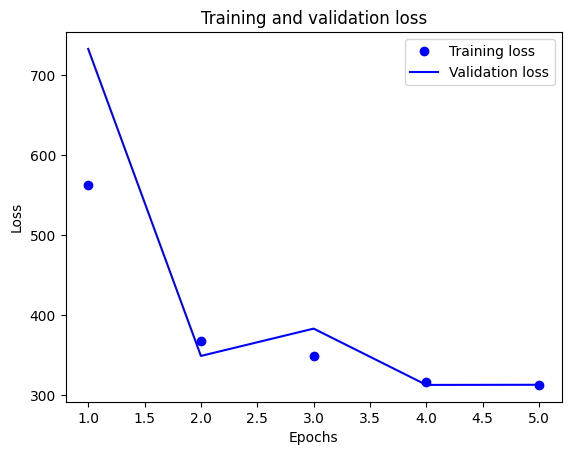

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(train_loss_all, val_loss_all)

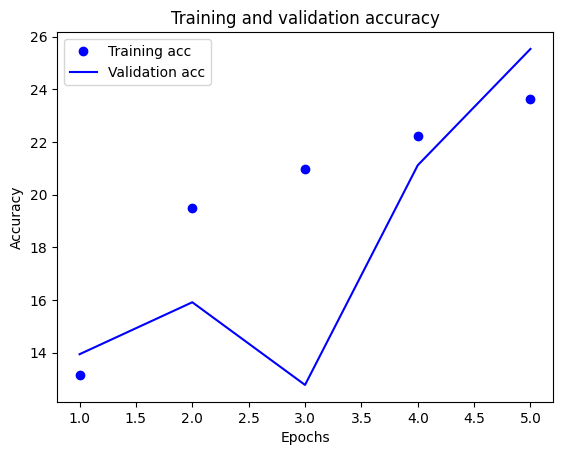

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)

In [ ]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 299.96, Test accuracy 24.96


In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.permute(1, 2, 0).numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [ ]:
imagenette_dataset = torchvision.datasets.Imagenette(root="../data/train_ex2", split = 'train', download=True)
print(imagenette_dataset.classes)

[('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]


In [ ]:
def get_imagenette_labels(labels):
    """Return text labels for the Imagenette dataset."""
    # Extract the primary label (first element of each tuple) from the provided list
    imagenette_raw_classes = [('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]
    imagenette_text_labels = [cls[0] for cls in imagenette_raw_classes]

    return [imagenette_text_labels[int(i)] for i in labels]

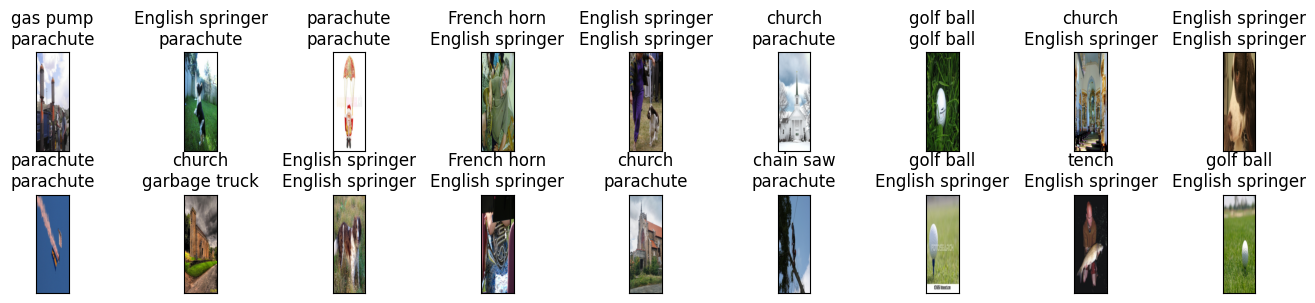

In [ ]:
def predict(net, test_iter, n=18):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_imagenette_labels(y)
    preds = get_imagenette_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 3, 300, 100)), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Problema 3

Classify the Imagenette dataset (10 classes) using an MLP.

**Data Acquisition and Preparation:**

- **Download:** Download the Imagenette train images.
- **Split Train Images:** Split the downloaded train images as follows:
  - Validation set: 5000 images.
  - Training set: 4000 images.
  - Testing dataset: The remaining images from the original train set will represent the testing dataset.
- **Batch Size:** Set the batch size to 150.

**MLP Architecture:**

- The MLP consists of five hidden layers.
- Each hidden layer has 128 units.
- The activation function used is the rectified linear unit (ReLU).
- A dropout layer should be added after the third hidden layer.
- The dropout probability for this layer is 35%.

**Model Initialization:**

- **Weights:** Set the weights from a normal distribution with a standard deviation (`std`) of 0.01.
- **Biases:** Set the biases to 0.

**Training Parameters:**

- **Learning Rate:** Set the learning rate to 0.15.
- **Epochs:** Train the model for 15 epochs.

**Evaluation:**

- Evaluate the trained model on the test set.

In [ ]:
def load_data_imagenette(batch_size, resize=None):
    """Download the Imagenette dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)

    imagenette_train = torchvision.datasets.Imagenette(
        root="../data/train_ex3", split = 'train', transform=trans, download=True)
    imagenette_train, imagenette_val, imagenette_test = torch.utils.data.random_split(imagenette_train, [4000, 5000, len(imagenette_train) - 4000 - 5000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(imagenette_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(imagenette_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(imagenette_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
batch_size = 150

In [ ]:
train_iter, val_iter, test_iter = load_data_imagenette(batch_size, resize = (300, 100))

100%|██████████| 1.56G/1.56G [00:33<00:00, 47.1MB/s]


In [ ]:
net = nn.Sequential(
    nn.Flatten(),
    # first hidden layer
    nn.Linear((3 * 300 * 100), 128),  # 90 000 in, 128 out (hidden units)
    nn.ReLU(),
    # second hidden layer
    nn.Linear(128, 128),
    nn.ReLU(),
    # third hidden layer
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(0.35),
    # fourth hidden layer
    nn.Linear(128, 128),
    nn.ReLU(),
    # fifth hidden layer
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 10)    # output layer with 10 classes
)

In [ ]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, mean = 0.0, std = 0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=90000, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=128, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.35, inplace=False)
  (8): Linear(in_features=128, out_features=128, bias=True)
  (9): ReLU()
  (10): Linear(in_features=128, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
loss = nn.CrossEntropyLoss()

In [ ]:
lr = 0.15
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [ ]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
num_epochs = 15
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

Epoch 1, Train loss 2.30, Train accuracy 10.53, Validation loss 2.30, Validation accuracy 9.76
Epoch 2, Train loss 2.30, Train accuracy 10.08, Validation loss 2.30, Validation accuracy 9.76
Epoch 3, Train loss 2.30, Train accuracy 9.98, Validation loss 2.30, Validation accuracy 9.86
Epoch 4, Train loss 2.30, Train accuracy 10.05, Validation loss 2.30, Validation accuracy 9.70
Epoch 5, Train loss 2.30, Train accuracy 10.57, Validation loss 2.30, Validation accuracy 9.70
Epoch 6, Train loss 2.30, Train accuracy 10.47, Validation loss 2.30, Validation accuracy 9.70
Epoch 7, Train loss 2.30, Train accuracy 10.40, Validation loss 2.30, Validation accuracy 9.70
Epoch 8, Train loss 2.30, Train accuracy 10.50, Validation loss 2.30, Validation accuracy 9.70
Epoch 9, Train loss 2.30, Train accuracy 9.85, Validation loss 2.30, Validation accuracy 9.70
Epoch 10, Train loss 2.30, Train accuracy 10.47, Validation loss 2.30, Validation accuracy 9.70
Epoch 11, Train loss 2.30, Train accuracy 10.55, Va

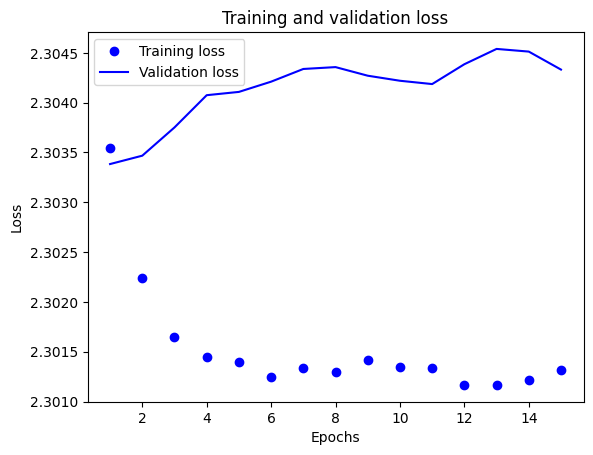

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(train_loss_all, val_loss_all)

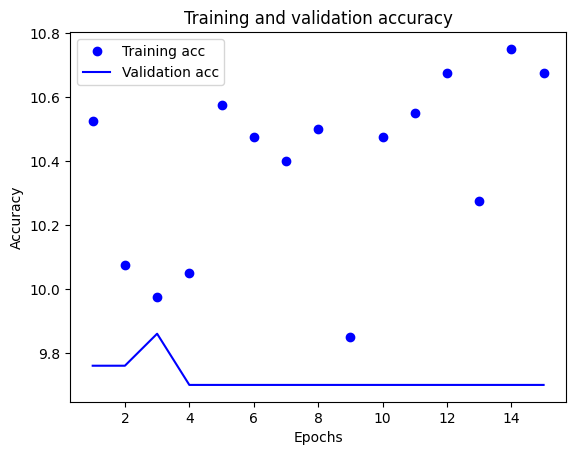

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)

In [ ]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 2.30, Test accuracy 8.10


In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.permute(1, 2, 0).numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [ ]:
imagenette_dataset = torchvision.datasets.Imagenette(root="../data/train_ex2", split = 'train', download=True)
print(imagenette_dataset.classes)

[('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]


In [ ]:
def get_imagenette_labels(labels):
    """Return text labels for the Imagenette dataset."""
    # Extract the primary label (first element of each tuple) from the provided list
    imagenette_raw_classes = [('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]
    imagenette_text_labels = [cls[0] for cls in imagenette_raw_classes]

    return [imagenette_text_labels[int(i)] for i in labels]

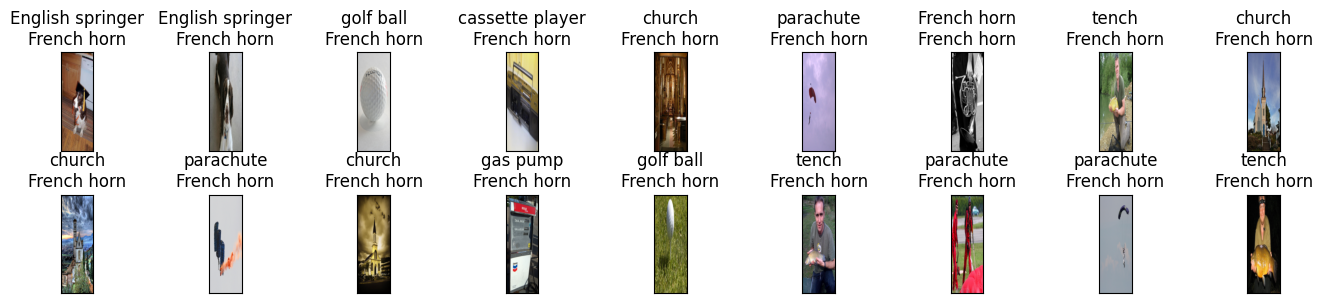

In [ ]:
def predict(net, test_iter, n=18):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_imagenette_labels(y)
    preds = get_imagenette_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 3, 300, 100)), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Problema 1.2

Apply a linear regression model on the "Wine Quality (red)" dataset.

**Dataset Details:**

- **Name:** Wine Quality (red) dataset
- **Size:** Contains 1599 examples
- **Features:** Each example has 11 numerical features describing various properties of red wines
- **Target:** A target quality score, which is an integer between 3 and 8
- **Preprocessing:**
  - All input features must be standardized by subtracting the mean and dividing by the standard deviation of each feature
  - The mean and standard deviation should be computed _only_ on the training set
- **Splitting:** The dataset needs to be split into:
  - A training set (80% of the data)
  - A testing set (20% of the data)

**Dataset Loading:**

```python
from sklearn.datasets import fetch_openml

data = fetch_openml(name="wine-quality-red", version=1, as_frame=True)
df = data.frame

X = df.drop("class", axis=1).values
y = df["class"].astype(np.float32).values
```

- `X` will contain the input features
- `y` will contain the target quality scores
- The target column is named "class"

**Linear Regression Model Creation and Training (Manual Implementation):**
The model must be created and trained **without using PyTorch's predefined layers** or the `torch.optim` package.
The training process should follow these steps:

- **Weights and Bias Initialization:** Initialize all model weights and the bias term to 0
- **Batch Size:** Set the batch size to 32
- **Loss Function:** Implement the Mean Squared Error (MSE) loss manually
- **Optimizer:** Implement the mini-batch gradient descent optimizer manually, with a learning rate (`lr`) of 0.01 (do not use `torch.optim`)
- **Epochs:** Set the total number of epochs to 40
- **Training Loop:** Train the model on the training set and record the training loss after each epoch

**Post-Training Evaluation:**
After the training is completed, the following evaluations are required:

- **Loss Curve Plot:** Plot the recorded training loss curve across all epochs
- **Test Set Evaluation:** Evaluate the trained model on the test set
- **Metrics:** Compute and report the Mean Squared Error (MSE) and Mean Absolute Error (MAE) on the test set

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import numpy as np

# Load the dataset
data = fetch_openml(name="wine-quality-red", version=1, as_frame=True)
df = data.frame

X = df.drop("class", axis=1).values
y = df["class"].astype(np.float32).values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the StandardScaler on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert all data to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train_scaled).float()
y_train_tensor = torch.from_numpy(y_train).float().reshape(-1, 1)
X_test_tensor = torch.from_numpy(X_test_scaled).float()
y_test_tensor = torch.from_numpy(y_test).float().reshape(-1, 1)

print("Data loading, splitting, standardization, and conversion to PyTorch tensors completed.")
print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")

Data loading, splitting, standardization, and conversion to PyTorch tensors completed.
X_train_tensor shape: torch.Size([1279, 11])
y_train_tensor shape: torch.Size([1279, 1])
X_test_tensor shape: torch.Size([320, 11])
y_test_tensor shape: torch.Size([320, 1])


In [ ]:
num_features = X_train_tensor.shape[1]
w = torch.zeros((num_features, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)


batch_size = 32
lr = 0.01
num_epochs = 40

train_iter = load_array((X_train_tensor, y_train_tensor), batch_size)

print(f"Initial weights (w):\n{w}")
print(f"Initial bias (b):\n{b}")
print(f"Number of features: {num_features}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {lr}")
print(f"Number of epochs: {num_epochs}")

Initial weights (w):
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], requires_grad=True)
Initial bias (b):
tensor([0.], requires_grad=True)
Number of features: 11
Batch size: 32
Learning rate: 0.01
Number of epochs: 40


In [ ]:
def mse_loss(y_pred, y_true):
    return ((y_pred - y_true)**2).mean()

**Reasoning**:
With the model parameters initialized and the loss function defined, the next step is to implement the training loop. This involves iterating over epochs and batches, making predictions, calculating the loss, computing gradients, updating the weights and bias manually using mini-batch gradient descent, and storing the training loss for plotting later.



In [ ]:
training_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_iter:
        # Make predictions
        y_pred = X_batch @ w + b

        # Calculate loss
        l = mse_loss(y_pred, y_batch)

        # Compute gradients
        l.backward()

        # Update weights and bias manually
        with torch.no_grad():
            w.data -= lr * w.grad
            b.data -= lr * b.grad

            # Zero the gradients after updating
            w.grad.zero_()
            b.grad.zero_()

        epoch_loss += l.item() * X_batch.shape[0] # Accumulate weighted loss for the epoch

    # Calculate average loss for the epoch
    avg_epoch_loss = epoch_loss / len(X_train_tensor)
    training_losses.append(avg_epoch_loss)
    print(f'Epoch {epoch + 1}, Loss: {avg_epoch_loss:.4f}')

print("Training completed.")

Epoch 1, Loss: 16.6033
Epoch 2, Loss: 3.6181
Epoch 3, Loss: 1.0603
Epoch 4, Loss: 0.5550
Epoch 5, Loss: 0.4552
Epoch 6, Loss: 0.4330
Epoch 7, Loss: 0.4292
Epoch 8, Loss: 0.4283
Epoch 9, Loss: 0.4280
Epoch 10, Loss: 0.4280
Epoch 11, Loss: 0.4279
Epoch 12, Loss: 0.4281
Epoch 13, Loss: 0.4281
Epoch 14, Loss: 0.4282
Epoch 15, Loss: 0.4278
Epoch 16, Loss: 0.4267
Epoch 17, Loss: 0.4267
Epoch 18, Loss: 0.4275
Epoch 19, Loss: 0.4279
Epoch 20, Loss: 0.4279
Epoch 21, Loss: 0.4276
Epoch 22, Loss: 0.4274
Epoch 23, Loss: 0.4275
Epoch 24, Loss: 0.4276
Epoch 25, Loss: 0.4268
Epoch 26, Loss: 0.4276
Epoch 27, Loss: 0.4274
Epoch 28, Loss: 0.4276
Epoch 29, Loss: 0.4275
Epoch 30, Loss: 0.4273
Epoch 31, Loss: 0.4272
Epoch 32, Loss: 0.4273
Epoch 33, Loss: 0.4270
Epoch 34, Loss: 0.4273
Epoch 35, Loss: 0.4272
Epoch 36, Loss: 0.4274
Epoch 37, Loss: 0.4275
Epoch 38, Loss: 0.4279
Epoch 39, Loss: 0.4265
Epoch 40, Loss: 0.4277
Training completed.


**Reasoning**:
The training is complete, and the training losses have been recorded. The next step is to visualize the training loss curve as required by the problem statement to understand the model's learning progress over epochs.



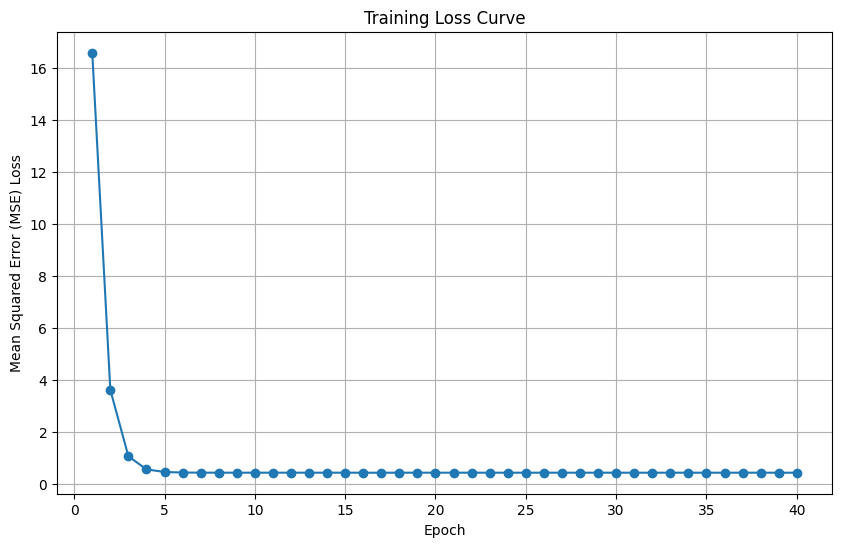

Training loss curve plotted.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), training_losses, marker='o', linestyle='-')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE) Loss')
plt.grid(True)
plt.show()

print("Training loss curve plotted.")

**Reasoning**:
With the training complete and the loss curve plotted, the final step is to evaluate the trained model on the test set using Mean Squared Error (MSE) and Mean Absolute Error (MAE), as specified in the problem statement.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions on the test set
y_test_pred = X_test_tensor @ w + b

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_tensor.detach().numpy(), y_test_pred.detach().numpy())

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_tensor.detach().numpy(), y_test_pred.detach().numpy())

print(f"\nTest Set Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


Test Set Evaluation:
Mean Squared Error (MSE): 0.3900
Mean Absolute Error (MAE): 0.5031


# Problema 2.2

Use the Oxford-IIIT Pet dataset.

**Dataset:**

- **Source:** Oxford-IIIT Pet dataset from `torchvision.datasets`
- **Content:** Contains 7,349 images of different cat and dog breeds
- **Labels:** Each image has a class label in the range `[0, 36]`
- **Splits:** Divided into two official subsets: `trainval` (training + validation data) and `test`

**Preprocessing steps for all images:**

- **Resizing:** Resize each image to a fixed resolution of `64 × 64` pixels
- **Tensor Conversion:** Convert each image to a PyTorch tensor with pixel values in the interval `[0, 1]`

**Dataset Splitting:**

- Use the entire `trainval` split to create a training set and a validation set by performing an `80% / 20%` random split
- Use the separate official `test` split as the final test set

**Multilayer Perceptron (MLP) Classifier Construction (using PyTorch):**

- **Hidden Layers:** 2 hidden layers
  - First layer: 512 hidden units
  - Second layer: 256 hidden units
  - Activation function: Rectified Linear Unit (ReLU) for both hidden layers
- **Dropout:** A dropout function after the first hidden layer with a dropout probability of `10%`

**Model Training Settings:**

- **Loss Function:** Use Cross-Entropy Loss
- **Optimizer:** Use the Adam optimizer with a learning rate (`lr`) of `0.001`
- **Batch Size:** Set the batch size to `64`
- **Epochs:** Train the model for `15` epochs
- **Recording per epoch:** After each epoch, compute and record:
  - Training loss
  - Training accuracy
  - Validation loss
  - Validation accuracy

**Post-Training Evaluation:**

- Plot both the training and validation loss curves
- Plot the training and validation accuracy curves
- Compute the test accuracy

In [ ]:
import torch
import torchvision
from torchvision import transforms

def load_data_oxford_pet(batch_size, resize=None):
    """Download the Oxford-IIIT Pet dataset and then load it into memory."""
    trans = []
    if resize:
        trans.append(transforms.Resize(resize))
    trans.append(transforms.ToTensor())
    trans = transforms.Compose(trans)

    # Load the 'trainval' split
    train_val_dataset = torchvision.datasets.OxfordIIITPet(
        root="../data/oxford_pet", split='trainval', transform=trans, download=True)

    # Split 'trainval' into training and validation sets (80/20 split)
    train_size = int(0.8 * len(train_val_dataset))
    val_size = len(train_val_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(train_val_dataset, [train_size, val_size],
                                                           generator=torch.Generator().manual_seed(42))

    # Load the 'test' split
    test_dataset = torchvision.datasets.OxfordIIITPet(
        root="../data/oxford_pet", split='test', transform=trans, download=True)

    # Create DataLoaders
    train_iter = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2)
    val_iter = torch.utils.data.DataLoader(val_dataset, batch_size, shuffle=False, num_workers=2)
    test_iter = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False, num_workers=2)

    return train_iter, val_iter, test_iter

# Call the function to get the data loaders
batch_size = 64
resize_dim = (64, 64)
train_iter, val_iter, test_iter = load_data_oxford_pet(batch_size, resize=resize_dim)

print("Oxford-IIIT Pet dataset loaded and DataLoaders created.")
print(f"Number of training batches: {len(train_iter)}")
print(f"Number of validation batches: {len(val_iter)}")
print(f"Number of test batches: {len(test_iter)}")


100%|██████████| 792M/792M [00:33<00:00, 23.9MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.27MB/s]


Oxford-IIIT Pet dataset loaded and DataLoaders created.
Number of training batches: 46
Number of validation batches: 12
Number of test batches: 58


In [ ]:
from torch import nn

# Calculate the input size for the flattened image
# 3 channels (RGB) * height * width
input_size = 3 * resize_dim[0] * resize_dim[1] # 3 * 64 * 64 = 12288
num_classes = 37 # Labels are in range [0, 36]

mlp_net = nn.Sequential(
    nn.Flatten(),
    # First hidden layer
    nn.Linear(input_size, 512),
    nn.ReLU(),
    # Dropout after the first hidden layer
    nn.Dropout(0.1),
    # Second hidden layer
    nn.Linear(512, 256),
    nn.ReLU(),
    # Output layer
    nn.Linear(256, num_classes)
)

print("MLP model architecture defined:")
print(mlp_net)

MLP model architecture defined:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=37, bias=True)
)


In [ ]:
loss = nn.CrossEntropyLoss()
lr = 0.001
optimizer = torch.optim.Adam(mlp_net.parameters(), lr=lr)

print("Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.")
print(f"Learning rate: {lr}")

Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.
Learning rate: 0.001


In [ ]:
def evaluate_accuracy(net, data_iter, loss_fn):
    """Compute the accuracy and loss for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss_fn(y_hat, y)
            total_loss += float(l) * X.shape[0]
            total_hits += (y_hat.argmax(axis=1) == y).sum().item()
            total_samples += y.numel()
    # Average loss per sample, not per batch
    return total_loss / total_samples, float(total_hits) / total_samples * 100

print("evaluate_accuracy function defined.")

evaluate_accuracy function defined.


In [ ]:
def train_epoch(net, train_iter, loss_fn, optimizer):
    """Train a model for one epoch."""
    net.train()  # Set the model to training mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Forward pass
        y_hat = net(X)
        l = loss_fn(y_hat, y)

        # Backward pass and optimize
        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        total_loss += float(l) * X.shape[0]
        total_hits += (y_hat.argmax(axis=1) == y).sum().item()
        total_samples += y.numel()

    # Average loss per sample, not per batch
    return total_loss / total_samples, float(total_hits) / total_samples * 100

print("train_epoch function defined.")

train_epoch function defined.


In [ ]:
def train(net, train_iter, val_iter, loss_fn, num_epochs, optimizer):
    """Train a model and record metrics."""
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss_fn, optimizer)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss_fn)

        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        print(f'Epoch {epoch + 1:d}: 'f'Train loss {train_loss:.3f}, Train accuracy {train_acc:.2f}%; 'f'Validation loss {val_loss:.3f}, Validation accuracy {val_acc:.2f}%')

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

print("train function defined.")

train function defined.


In [ ]:
num_epochs = 15
print(f"Starting training for {num_epochs} epochs...")
train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist = train(mlp_net, train_iter, val_iter, loss, num_epochs, optimizer)
print("Training completed.")

Starting training for 15 epochs...


/tmp/ipython-input-4063977086.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l) * X.shape[0]


Epoch 1: Train loss 3.690, Train accuracy 3.50%; Validation loss 3.519, Validation accuracy 5.71%
Epoch 2: Train loss 3.493, Train accuracy 5.98%; Validation loss 3.430, Validation accuracy 8.70%
Epoch 3: Train loss 3.437, Train accuracy 7.00%; Validation loss 3.422, Validation accuracy 6.93%
Epoch 4: Train loss 3.410, Train accuracy 7.37%; Validation loss 3.395, Validation accuracy 7.61%
Epoch 5: Train loss 3.364, Train accuracy 7.61%; Validation loss 3.398, Validation accuracy 7.07%
Epoch 6: Train loss 3.326, Train accuracy 8.59%; Validation loss 3.371, Validation accuracy 7.34%
Epoch 7: Train loss 3.287, Train accuracy 9.88%; Validation loss 3.461, Validation accuracy 7.07%
Epoch 8: Train loss 3.282, Train accuracy 9.58%; Validation loss 3.344, Validation accuracy 7.47%
Epoch 9: Train loss 3.225, Train accuracy 10.50%; Validation loss 3.318, Validation accuracy 9.24%
Epoch 10: Train loss 3.182, Train accuracy 11.92%; Validation loss 3.344, Validation accuracy 8.15%
Epoch 11: Train l

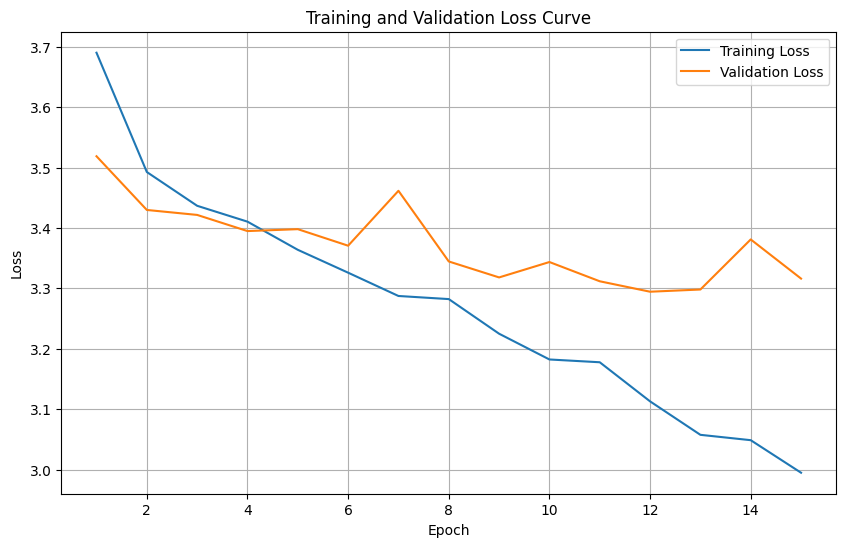

Training and validation loss curves plotted.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_loss_hist, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_loss_hist, label='Validation Loss')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Training and validation loss curves plotted.")

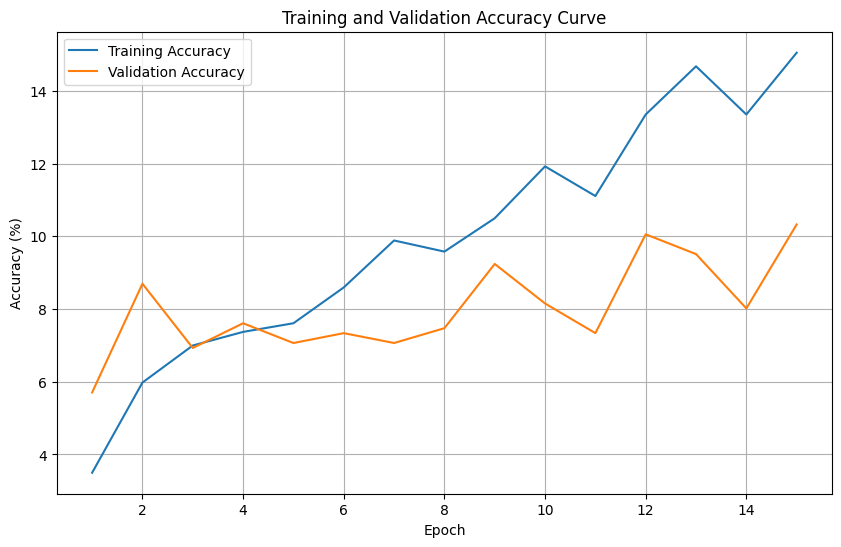

Training and validation accuracy curves plotted.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_acc_hist, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_acc_hist, label='Validation Accuracy')
plt.title('Training and Validation Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

print("Training and validation accuracy curves plotted.")

In [ ]:
test_loss, test_acc = evaluate_accuracy(mlp_net, test_iter, loss)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 8.45%


# Problema 2.3

Generate an artificial regression dataset and train a Multilayer Perceptron (MLP) model using PyTorch.

**1. Dataset Generation:**

- **Type:** Artificial regression dataset
- **Input Features:** 3 input features, denoted as `x = (x0, x1, x2)`
- **Input Distribution:** Each sample `x` is drawn independently from a uniform distribution on `[-2, 2]³`
- **Target Function:** The target value `y` is defined by the equation:
  `y = sin(x0) + 0.5 * x1² - x2 + ε`
  where `ε` (epsilon) represents Gaussian noise, distributed as `N(0, 0.1²)`

**2. Dataset Splitting:**

- **Total Samples:** Generate 10,000 samples
- **Splits:**
  - Training set: 70% of samples
  - Validation set: 15% of samples
  - Test set: 15% of samples

**3. MLP Regression Model Construction (using PyTorch):**

- **Architecture:** The MLP will consist of 3 hidden layers
- **Hidden Units:** Each of the 3 hidden layers will have 64 hidden units
- **Activation Function:** Rectified Linear Unit (ReLU) activation function for all hidden layers

**4. Model Training Settings:**

- **Loss Function:** Mean Squared Error (MSE)
- **Optimizer:** Adam optimizer
- **Learning Rate (`lr`):** 0.001
- **Batch Size:** 64
- **Number of Epochs:** 50

**5. Post-Training Evaluation:**

- **Plotting:**
  - Plot the training loss curve
  - Plot the validation loss curve
- **Metrics:**
  - Compute the Mean Squared Error (MSE) on the test set
  - Compute the Mean Absolute Error (MAE) on the test set


In [ ]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split

torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported and random seeds set for reproducibility.")

Libraries imported and random seeds set for reproducibility.


In [ ]:
def generate_regression_data(num_samples):
    # Generate 3-dimensional input features (x0, x1, x2) from a uniform distribution on [-2, 2]
    X = (torch.rand(num_samples, 3) * 4) - 2 # Scale to [-2, 2]

    # Generate Gaussian noise epsilon from N(0, 0.1^2)
    epsilon = torch.normal(0, 0.1, (num_samples, 1))

    # Calculate target values y = sin(x0) + 0.5 * x1^2 - x2 + epsilon
    x0, x1, x2 = X[:, 0].reshape(-1, 1), X[:, 1].reshape(-1, 1), X[:, 2].reshape(-1, 1)
    y = torch.sin(x0) + 0.5 * (x1**2) - x2 + epsilon

    return X, y

# Generate 10,000 samples
num_total_samples = 10000
X_data, y_data = generate_regression_data(num_total_samples)

print(f"Generated X_data shape: {X_data.shape}")
print(f"Generated y_data shape: {y_data.shape}")

Generated X_data shape: torch.Size([10000, 3])
Generated y_data shape: torch.Size([10000, 1])


In [ ]:
num_total_samples = 10000
train_size = int(0.7 * num_total_samples)
val_size = int(0.15 * num_total_samples)
test_size = num_total_samples - train_size - val_size

dataset = TensorDataset(X_data, y_data)

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size],
                                                        generator=torch.Generator().manual_seed(42))


batch_size = 64

# The load_array function was previously defined in the notebook, assuming it's available.
# It creates a DataLoader. For random_split, we can directly create DataLoader from the split datasets.

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Extract X and y for each split to print shapes (for verification purposes)
X_train = train_dataset[:][0]
y_train = train_dataset[:][1]
X_val = val_dataset[:][0]
y_val = val_dataset[:][1]
X_test = test_dataset[:][0]
y_test = test_dataset[:][1]

print(f"Training set size: {len(train_dataset)} samples")
print(f"Validation set size: {len(val_dataset)} samples")
print(f"Test set size: {len(test_dataset)} samples")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

print("Dataset split and DataLoaders created successfully.")

Training set size: 7000 samples
Validation set size: 1500 samples
Test set size: 1500 samples
X_train shape: torch.Size([7000, 3]), y_train shape: torch.Size([7000, 1])
X_val shape: torch.Size([1500, 3]), y_val shape: torch.Size([1500, 1])
X_test shape: torch.Size([1500, 3]), y_test shape: torch.Size([1500, 1])
Number of training batches: 110
Number of validation batches: 24
Number of test batches: 24
Dataset split and DataLoaders created successfully.


In [ ]:
from torch import nn

mlp_net = nn.Sequential(
    nn.Linear(3, 64), # Input layer (3 features) to first hidden layer (64 units)
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1) # Output layer (1 unit for regression)
)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        if m.bias is not None:
            m.bias.data.fill_(0.0)

mlp_net.apply(init_weights)

print("MLP Regression Model architecture defined:")
print(mlp_net)
print("Weights and biases initialized.")

MLP Regression Model architecture defined:
Sequential(
  (0): Linear(in_features=3, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=1, bias=True)
)
Weights and biases initialized.


In [ ]:
loss_fn = nn.MSELoss() # Mean Squared Error loss
lr = 0.001 # Learning rate
optimizer = torch.optim.Adam(mlp_net.parameters(), lr=lr) # Adam optimizer
num_epochs = 50 # Number of epochs

print("Loss function (MSELoss), Optimizer (Adam), Learning Rate, and Number of Epochs defined.")
print(f"Learning rate: {lr}")
print(f"Number of epochs: {num_epochs}")

Loss function (MSELoss), Optimizer (Adam), Learning Rate, and Number of Epochs defined.
Learning rate: 0.001
Number of epochs: 50


In [ ]:
def train_epoch(net, train_loader, loss_fn, optimizer):
    """Train a model for one epoch and return average loss and an empty accuracy (since it's regression)."""
    net.train() # Set the model to training mode

    total_loss = 0
    total_samples = 0
    for X_batch, y_batch in train_loader:
        # Forward pass
        y_pred = net(X_batch)
        l = loss_fn(y_pred, y_batch)

        # Backward pass and optimize
        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        total_loss += l.item() * X_batch.shape[0]
        total_samples += X_batch.shape[0]

    # Return training loss. Accuracy is not applicable for regression.
    return total_loss / total_samples

print("train_epoch function defined for regression.")

train_epoch function defined for regression.


In [ ]:
def evaluate_model(net, data_loader, loss_fn):
    """Compute the average loss for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_samples = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            y_pred = net(X_batch)
            l = loss_fn(y_pred, y_batch)
            total_loss += l.item() * X_batch.shape[0]
            total_samples += X_batch.shape[0]

    # Average loss per sample
    return total_loss / total_samples

print("evaluate_model function defined for regression (calculates loss only).")

evaluate_model function defined for regression (calculates loss only).


In [ ]:
def train(net, train_loader, val_loader, loss_fn, optimizer, num_epochs):
    """Train the model and record training and validation loss per epoch."""
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss = train_epoch(net, train_loader, loss_fn, optimizer)
        train_losses.append(train_loss)

        # Evaluate on validation set
        val_loss = evaluate_model(net, val_loader, loss_fn)
        val_losses.append(val_loss)

        print(f'Epoch {epoch + 1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    return train_losses, val_losses

print("train function defined.")

train function defined.


In [ ]:
print(f"Starting training for {num_epochs} epochs...")
train_losses, val_losses = train(mlp_net, train_loader, val_loader, loss_fn, optimizer, num_epochs)
print("Training completed.")

Starting training for 50 epochs...
Epoch 1/50: Train Loss: 1.2780, Val Loss: 0.1948
Epoch 2/50: Train Loss: 0.0820, Val Loss: 0.0594
Epoch 3/50: Train Loss: 0.0492, Val Loss: 0.0442
Epoch 4/50: Train Loss: 0.0367, Val Loss: 0.0347
Epoch 5/50: Train Loss: 0.0293, Val Loss: 0.0306
Epoch 6/50: Train Loss: 0.0260, Val Loss: 0.0272
Epoch 7/50: Train Loss: 0.0236, Val Loss: 0.0231
Epoch 8/50: Train Loss: 0.0206, Val Loss: 0.0207
Epoch 9/50: Train Loss: 0.0181, Val Loss: 0.0184
Epoch 10/50: Train Loss: 0.0172, Val Loss: 0.0186
Epoch 11/50: Train Loss: 0.0152, Val Loss: 0.0154
Epoch 12/50: Train Loss: 0.0145, Val Loss: 0.0225
Epoch 13/50: Train Loss: 0.0141, Val Loss: 0.0141
Epoch 14/50: Train Loss: 0.0130, Val Loss: 0.0158
Epoch 15/50: Train Loss: 0.0130, Val Loss: 0.0132
Epoch 16/50: Train Loss: 0.0131, Val Loss: 0.0194
Epoch 17/50: Train Loss: 0.0130, Val Loss: 0.0150
Epoch 18/50: Train Loss: 0.0128, Val Loss: 0.0127
Epoch 19/50: Train Loss: 0.0130, Val Loss: 0.0170
Epoch 20/50: Train Loss:

**Reasoning**:
The training is complete, and the training and validation losses have been recorded. The next step is to plot these losses over epochs as required by the problem statement to visualize the model's learning progress.



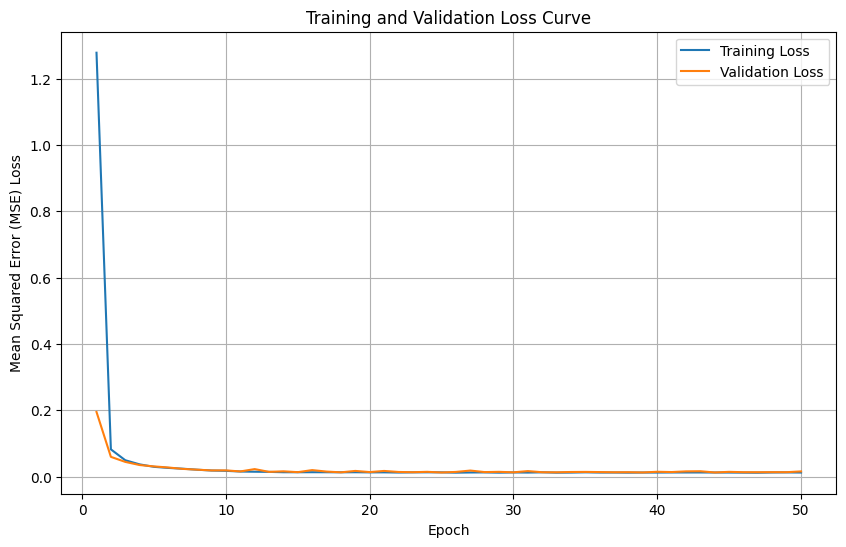

Training and validation loss curves plotted.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE) Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Training and validation loss curves plotted.")

In [ ]:
from sklearn.metrics import mean_absolute_error

# Make predictions on the test set
mlp_net.eval() # Set the model to evaluation mode
with torch.no_grad():
    y_test_pred = mlp_net(X_test)

# Calculate Mean Squared Error (MSE) using the previously defined loss_fn (nn.MSELoss)
mse_test = loss_fn(y_test_pred, y_test).item()

# Calculate Mean Absolute Error (MAE)
mae_test = mean_absolute_error(y_test.numpy(), y_test_pred.numpy())

print(f"\nTest Set Evaluation:")
print(f"Mean Squared Error (MSE) on Test Set: {mse_test:.4f}")
print(f"Mean Absolute Error (MAE) on Test Set: {mae_test:.4f}")


Test Set Evaluation:
Mean Squared Error (MSE) on Test Set: 0.0151
Mean Absolute Error (MAE) on Test Set: 0.0979


# Problema 1  - PI



Estimate the following linear model $y = 1 \cdot X - 1 + \epsilon$, where $X \in \mathbb{R}^{60 \times 1}$ consists of generated values from $-3$ to $3$ and $\epsilon$ obeys a normal distribution with mean $0$ and standard deviation of $0.1$. Train the linear regression model as follows:

* set the weights and bias to $1$;
* set the batch size to $10$;
* **implement** the mean squared error loss;
* **implement** the mini-batch gradient descent optimizer, $lr = 0.05$ (do not use the `torch.optim` package);
* set the total number of iterations to $25$;

After the model is trained, compare the learned model parameters with the actual parameters.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [2]:
def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape(-1, 1)

In [3]:
true_w = torch.tensor([1.0])
true_b = torch.tensor([-1.0])

# pentru ca avem 60 * 1
features, labels = synthetic_data(true_w, true_b, 60)

In [4]:
print('Features:', features[0], '\nLabel:', labels[0])

Features: tensor([1.9269]) 
Label: tensor([0.9289])


In [6]:
# `nn` is an abbreviation for neural networks
from torch import nn

net = nn.Sequential(nn.Linear(1, 1))    # one input, one output

In [7]:
# set the weights and bias to 1
net[0].weight.data.fill_(1)
net[0].bias.data.fill_(1)

tensor([1.])

In [16]:
# implement the mean squared error function

def loss_function(y_pred, y):
  return torch.mean((y_pred - y) ** 2)

In [9]:
batch_size = 10
lr = 0.05
num_iterations = 25

In [10]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [11]:
data_iter = load_array((features, labels), batch_size)

In [19]:
iteration = 0

while iteration < num_iterations:
  for X,y in data_iter:
    if iteration >= num_iterations:
      break

    l = loss_function(net(X), y)
    l.backward()

    net[0].weight.data = net[0].weight.data - lr * net[0].weight.grad.data
    net[0].bias.data = net[0].bias.data - lr * net[0].bias.grad.data

    net[0].weight.grad.data.zero_()
    net[0].bias.grad.data.zero_()

    iteration += 1

  l = loss_function(net(features), labels)
  print(f'epoch {iteration}, loss {l:f}')


# daca era cu epoci, faceam ca mai sus

epoch 6, loss 0.000218
epoch 12, loss 0.000146
epoch 18, loss 0.000119
epoch 24, loss 0.000109
epoch 25, loss 0.000109


# Problema 2 - PI

Implement the softmax regression model in order to classify the images from the MNIST dataset ($28 \times 28$ images of handwritten digits, $10$ classes, labels are the digits from $0$ to $9$, $60000$ training images and $10000$ testing images) as follows:

* set the batch size to $100$;
* the validation dataset consists of $30000$ images and the rest represents the training dataset;
* set the weights to $1$;
* use the cross-entropy loss function;
* use mini-batch stochastic gradient descent with a learning rate of $0.15$ as the optimization algorithm;
* set the number of epochs to $15$;
* plot the accuracy for the training and validation sets;
* use the trained model to classify $20$ images.

Evaluate the trained model on the test set.

In [21]:
import torchvision
from torchvision import transforms
import torch
from torch import nn

In [52]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.MNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.MNIST(
        root="../data", train=False, transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [30000, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [53]:
batch_size = 100
train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 395kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.56MB/s]


In [55]:
net = nn.Sequential(nn.Flatten(), nn.Linear((28 * 28), 10))

In [56]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight, 1)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

In [57]:
loss = nn.CrossEntropyLoss()

In [58]:
lr = 0.15
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [59]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [60]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [61]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [62]:
num_epochs = 15
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

Epoch 1, Train loss 0.58, Train accuracy 85.85, Validation loss 0.41, Validation accuracy 88.91
Epoch 2, Train loss 0.37, Train accuracy 89.80, Validation loss 0.37, Validation accuracy 89.62
Epoch 3, Train loss 0.34, Train accuracy 90.68, Validation loss 0.35, Validation accuracy 90.27
Epoch 4, Train loss 0.32, Train accuracy 91.05, Validation loss 0.34, Validation accuracy 90.54
Epoch 5, Train loss 0.31, Train accuracy 91.41, Validation loss 0.33, Validation accuracy 90.74
Epoch 6, Train loss 0.30, Train accuracy 91.69, Validation loss 0.32, Validation accuracy 90.77
Epoch 7, Train loss 0.29, Train accuracy 91.87, Validation loss 0.32, Validation accuracy 90.77
Epoch 8, Train loss 0.29, Train accuracy 91.91, Validation loss 0.32, Validation accuracy 91.04
Epoch 9, Train loss 0.28, Train accuracy 92.14, Validation loss 0.31, Validation accuracy 91.14
Epoch 10, Train loss 0.28, Train accuracy 92.28, Validation loss 0.31, Validation accuracy 91.19
Epoch 11, Train loss 0.28, Train accura

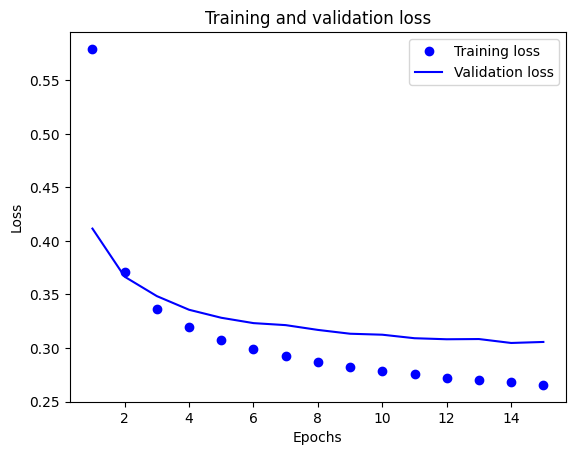

In [63]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(train_loss_all, val_loss_all)

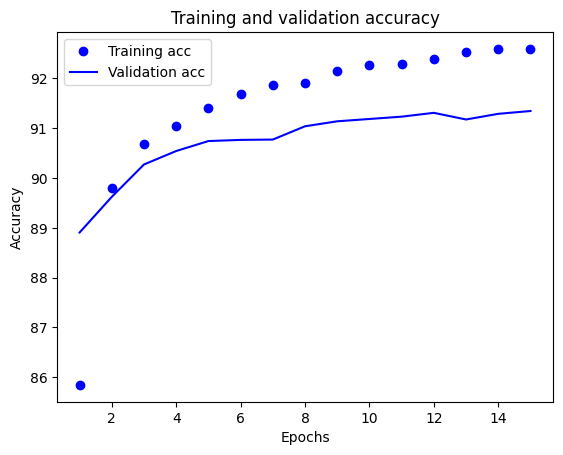

In [64]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)

In [65]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 0.28, Test accuracy 91.95


In [66]:
def get_fashion_mnist_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['0','1', '2', '3', '4', '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

In [67]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

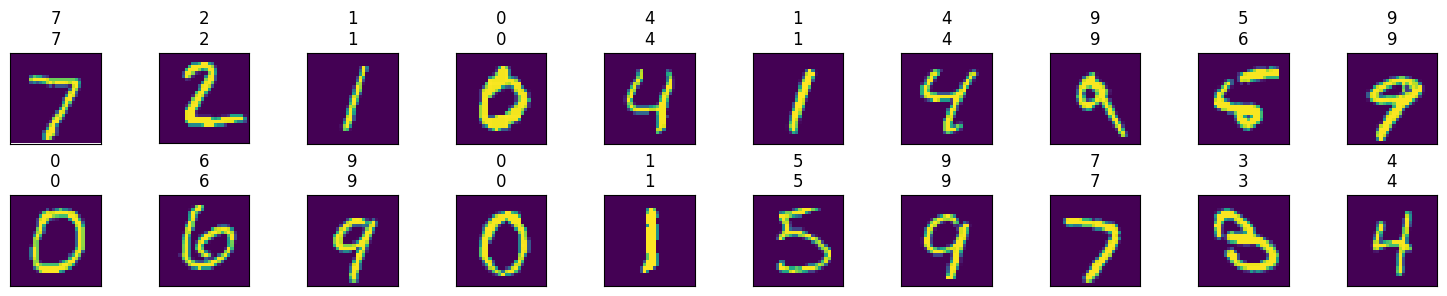

In [85]:
def predict(net, test_iter, n=20):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Problema 3 - PI

Classify the MNIST dataset ($28 \times 28$ images, $10$ classes, $60000$ training images and $10000$ testing images) using an MLP as follows:

* two hidden layers with $256$ units;
* add the hyperbolic tangent activation function and a dropout layer after each hidden layer (dropout probability of $40\%$);
* use $45000$ training images and $15000$ validation images;
* use the cross-entropy loss function;
* apply Xavier initialization to the weights and set the biases to zero;
* set the batch size to $512$ and the learning rate to $0.15$;
* train the model for $10$ epochs.

Evaluate the trained model on the test set.

In [69]:
import torchvision
from torchvision import transforms
import torch
from torch import nn

In [72]:
def load_data_mnist(batch_size, resize=None):
    """Download the MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.MNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.MNIST(
        root="../data", train=False, transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [30000, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [73]:
batch_size = 100
train_iter, val_iter, test_iter = load_data_mnist(batch_size)

In [74]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.Tanh(),
    nn.Dropout(0.4),
    nn.Linear(256, 256),
    nn.Tanh(),
    nn.Dropout(0.4),
    nn.Linear(256, 10)
)

In [75]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
        nn.init.constant_(m.bias, 0)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Tanh()
  (6): Dropout(p=0.4, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

In [76]:
loss = nn.CrossEntropyLoss()

In [77]:
lr = 0.15
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [78]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [79]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [80]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [81]:
num_epochs = 15
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, loss, num_epochs, optimizer)

Epoch 1, Train loss 0.51, Train accuracy 84.43, Validation loss 0.32, Validation accuracy 90.55
Epoch 2, Train loss 0.36, Train accuracy 89.22, Validation loss 0.30, Validation accuracy 91.01
Epoch 3, Train loss 0.32, Train accuracy 90.39, Validation loss 0.28, Validation accuracy 91.81
Epoch 4, Train loss 0.30, Train accuracy 91.11, Validation loss 0.27, Validation accuracy 92.23
Epoch 5, Train loss 0.27, Train accuracy 91.90, Validation loss 0.24, Validation accuracy 93.01
Epoch 6, Train loss 0.26, Train accuracy 92.34, Validation loss 0.23, Validation accuracy 93.45
Epoch 7, Train loss 0.24, Train accuracy 92.75, Validation loss 0.21, Validation accuracy 93.86
Epoch 8, Train loss 0.23, Train accuracy 92.84, Validation loss 0.21, Validation accuracy 94.01
Epoch 9, Train loss 0.22, Train accuracy 93.24, Validation loss 0.19, Validation accuracy 94.42
Epoch 10, Train loss 0.21, Train accuracy 93.63, Validation loss 0.19, Validation accuracy 94.32
Epoch 11, Train loss 0.20, Train accura

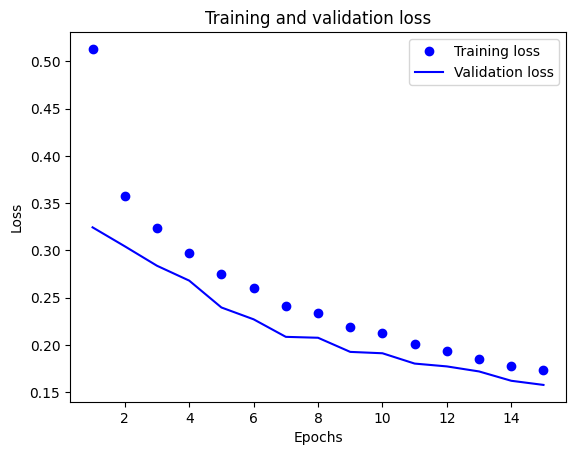

In [82]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(train_loss_all, val_loss_all)

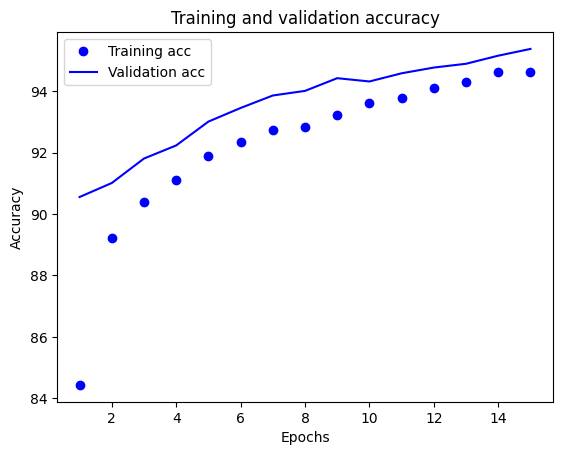

In [83]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)

In [84]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

Test loss 0.14, Test accuracy 95.78


In [86]:
def get_fashion_mnist_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['0','1', '2', '3', '4', '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

In [87]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

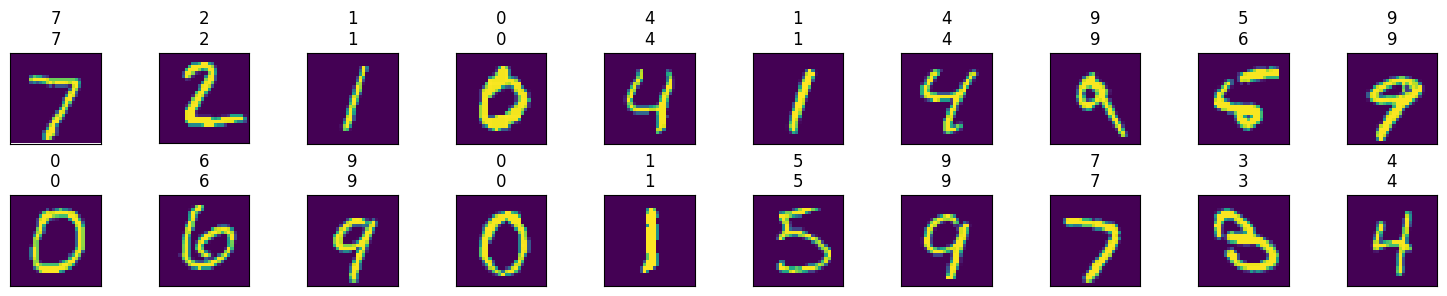

In [88]:
def predict(net, test_iter, n=20):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)